# core

> Fill in a module description here

In [1]:
#| default_exp core
%load_ext autoreload
%autoreload 2

In [12]:
#| hide
import sys
import os
import matplotlib.pyplot as plt

sys.path.append("..")

import numpy as np

from scipy.interpolate import CubicSpline

from CIGNN_experimental.unipen_renderer.parser import Parser
from CIGNN_experimental.unipen_renderer.strokes_to_image_converter import Strokes2ImageConverter
splines = np.load("../CIGNN_experimental/unipen_renderer/unipen_strokes.npy", allow_pickle=True).item()
splines.keys()

dict_keys([98, 117, 116, 45, 102, 101, 119, 109, 111, 114, 103, 105, 110, 33, 65, 121, 100, 63, 68, 39, 108, 115, 97, 99, 104, 46, 58, 59, 57, 56, 55, 43, 52, 53, 54, 49, 50, 51, 48, 42, 81, 85, 69, 82, 83, 75, 74, 79, 84, 72, 87, 89, 90, 73, 77, 67, 106, 113, 107, 112, 118, 120, 122, 88, 36, 34, 66, 70, 71, 76, 78, 80, 44, 86, 61, 64, 40, 41, 125, 35, 123, 37, 38, 47, 60, 96, 126, 93, 94, 124, 62, 91, 92, 95])

In [7]:
# Reduce the problem by only considering three classes: capital A, B and C 
splines = {cls: splines[cls] for cls in [65, 66, 67, 68, 69]}

# Choose one prototype per class 
prototypes = []
for cls in list(splines.keys()):
    # Keep track of how many recordings we have for each class 
    print(f"Class {cls}: {len(splines[cls])} #items")

    # Randomly choose one sample of each class as prototype.
    # For now just use one prototype per class
    rand_idx = np.random.choice(len(splines[cls]))  
    prototypes.append(splines[cls][rand_idx])

Class 65: 1401 #items
Class 66: 891 #items
Class 67: 967 #items
Class 68: 931 #items
Class 69: 1681 #items


In [8]:
# Load the transformations

# I have put them in a separate file now to later include them into the pipeline
from CIGNN_experimental.stroke_transforms import random_move, random_move_stroke, smooth_strokes, shorten, prolong, merge_points, skip_points, merge_strokes, split_strokes


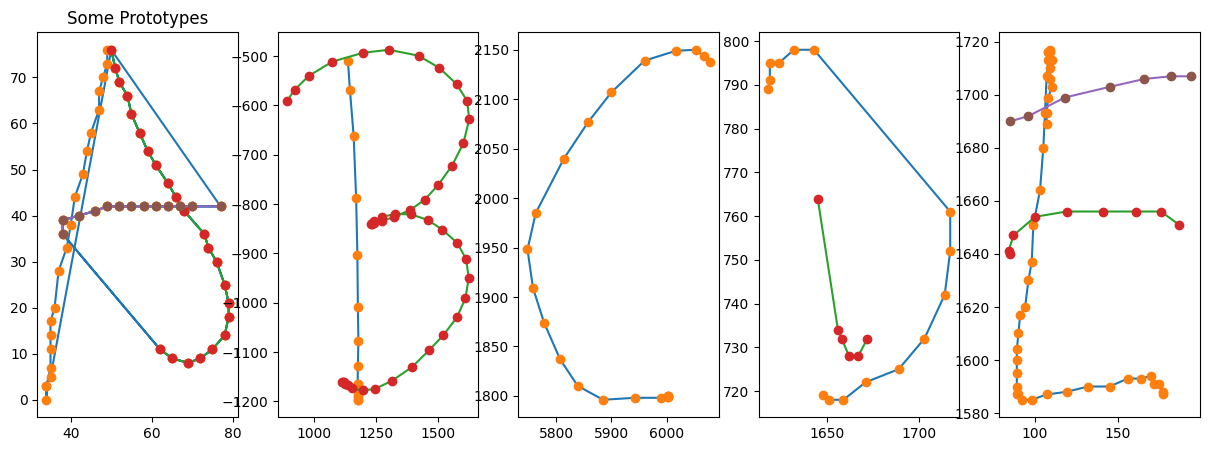

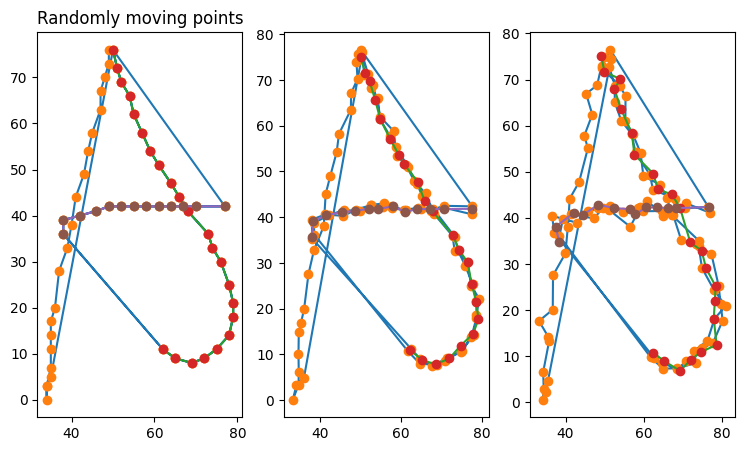

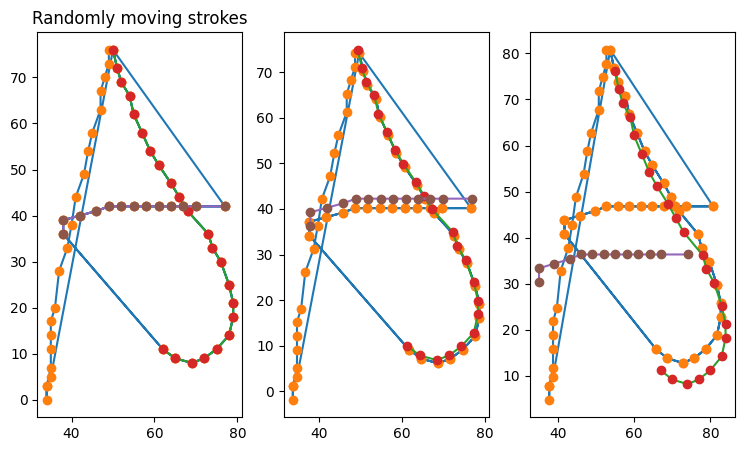

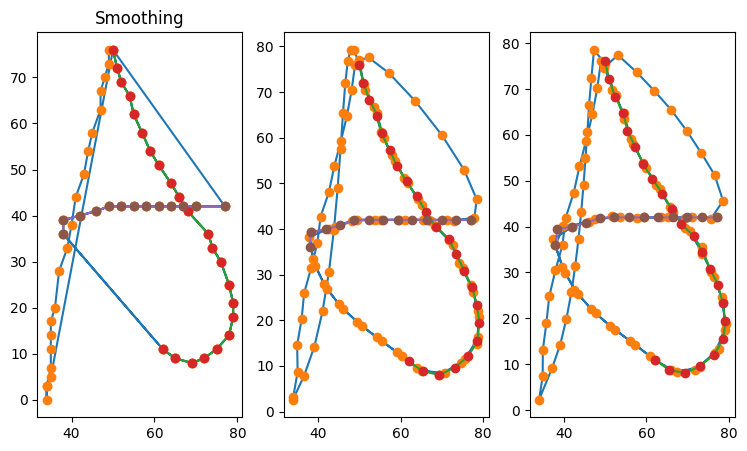

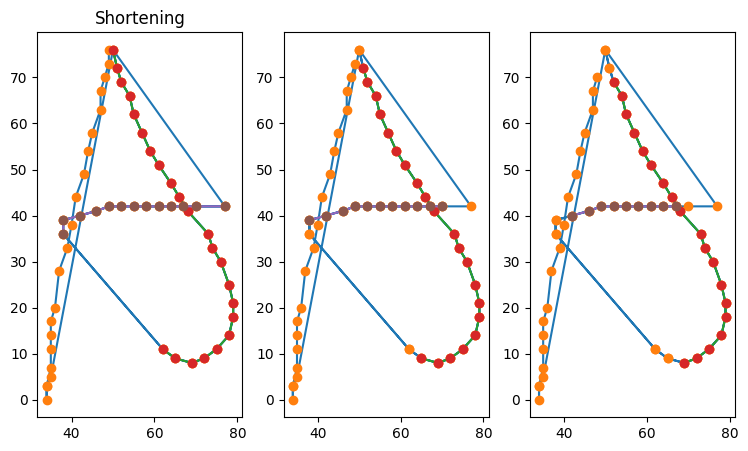

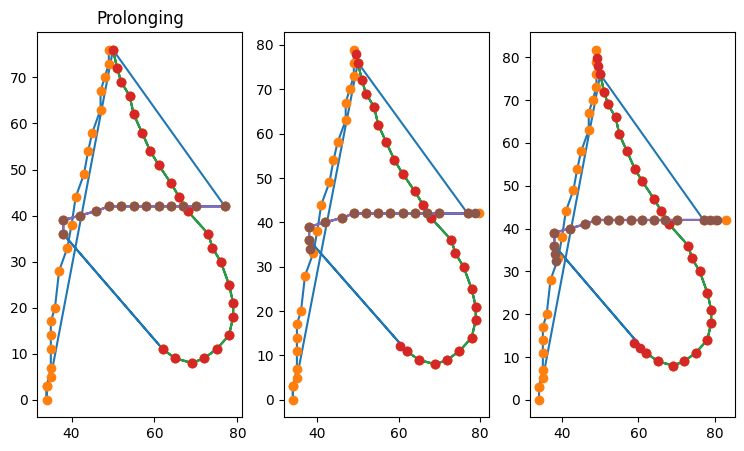

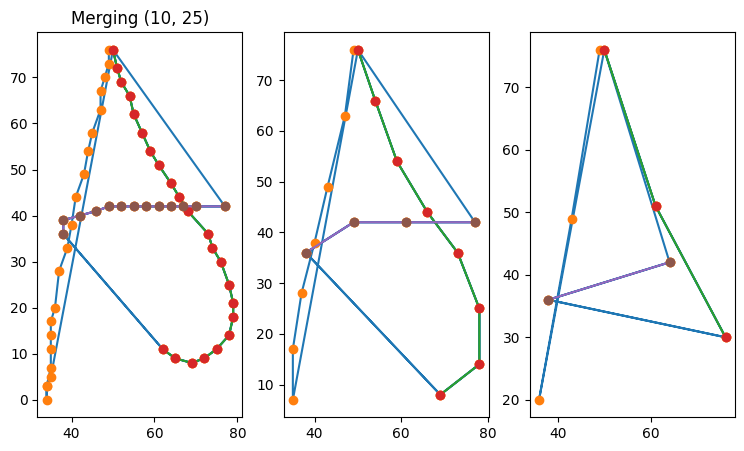

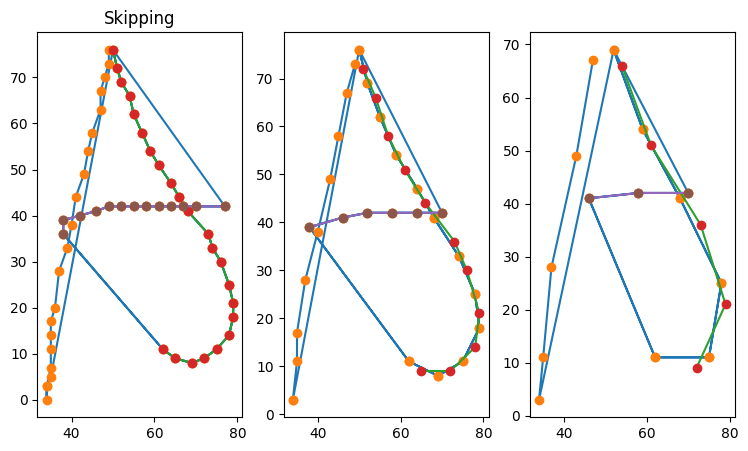

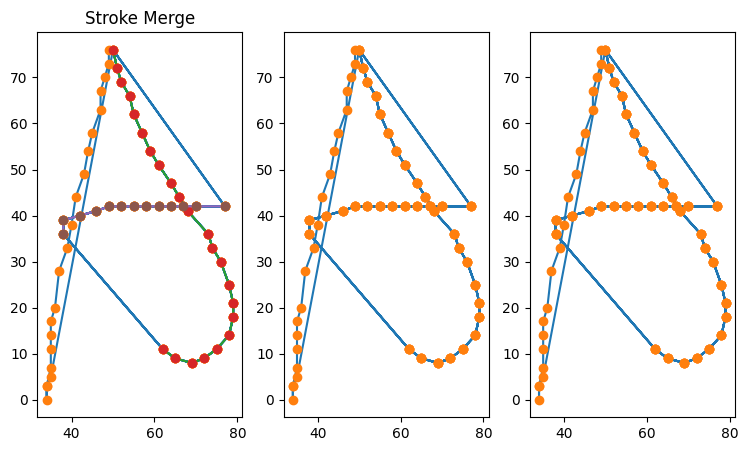

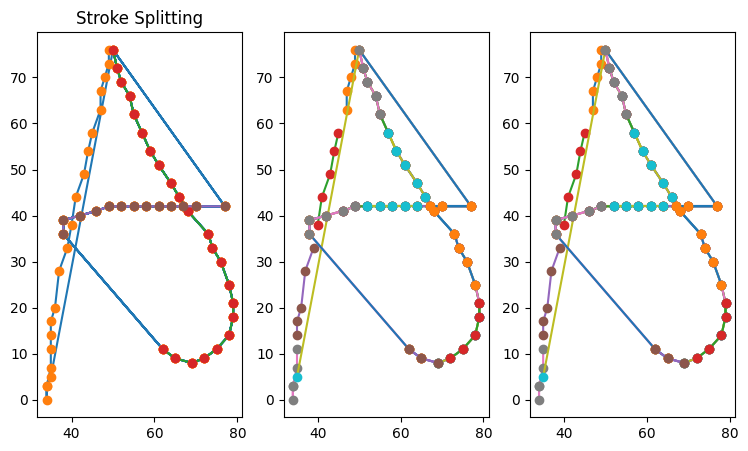

In [10]:
def render_samples(samples, title=""):
    fig, axes = plt.subplots(nrows=1, ncols=len(samples), figsize=(len(samples) * 3, 5))
    axes[0].title.set_text(title)
    
    for idx, sample in enumerate(samples):
        for stroke in sample:
            arr_stroke = np.array(stroke)
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1])
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1], "o")

    
    fig.show()
    
render_samples(prototypes, "Some Prototypes")
render_samples([prototypes[0], random_move(prototypes[0], max_dist=(.5, .5)), random_move(prototypes[0], max_dist=(1, 1))], "Randomly moving points")
render_samples([prototypes[0], random_move_stroke(prototypes[0], max_dist=(3, 3)), random_move_stroke(prototypes[0], max_dist=(6, 6))], "Randomly moving strokes")
render_samples([prototypes[0], smooth_strokes(prototypes[0]), smooth_strokes(smooth_strokes(prototypes[0]))], "Smoothing")
render_samples([prototypes[0], shorten(prototypes[0]), shorten(shorten(prototypes[0]))], "Shortening")
render_samples([prototypes[0], prolong(prototypes[0]), prolong(prolong(prototypes[0]))], "Prolonging")
render_samples([prototypes[0], merge_points(prototypes[0], 10), merge_points(prototypes[0], 25)], "Merging (10, 25)")
render_samples([prototypes[0], skip_points(prototypes[0]), skip_points(skip_points(prototypes[0]))], "Skipping")
render_samples([prototypes[0], merge_strokes(prototypes[0]), merge_strokes(merge_strokes(prototypes[0]))], "Stroke Merge")
render_samples([prototypes[0], split_strokes(prototypes[0]), split_strokes(split_strokes(prototypes[0]))], "Stroke Splitting")



In [14]:
# Crossover methods

def spline_crossover(prototype1, prototype2):
    """
    Perform spline-based crossover between two prototypes.

    Args:
        prototype1: First parent prototype (list of strokes).
        prototype2: Second parent prototype (list of strokes).
        num_points: Number of points to sample from the combined spline.

    Returns:
        offspring: New prototype generated from the crossover.
    """
    offspring = []

    for stroke1, stroke2 in zip(prototype1, prototype2):
        # Fit cubic splines to both parent strokes
        points1 = np.array(stroke1)
        points2 = np.array(stroke2)
        t1 = np.linspace(0, 1, len(points1))
        t2 = np.linspace(0, 1, len(points2))
        cs_x1 = CubicSpline(t1, points1[:, 0])
        cs_y1 = CubicSpline(t1, points1[:, 1])
        cs_x2 = CubicSpline(t2, points2[:, 0])
        cs_y2 = CubicSpline(t2, points2[:, 1])

        # Combine the splines (e.g., using single-point crossover)
        t_combined = np.linspace(0, 1, (len(stroke1) + len(stroke2)) // 2)
        x_combined = (cs_x1(t_combined) + cs_x2(t_combined)) / 2
        y_combined = (cs_y1(t_combined) + cs_y2(t_combined)) / 2

        # Create the offspring stroke
        offspring_stroke = list(zip(x_combined, y_combined))
        offspring.append(offspring_stroke)

    return offspring

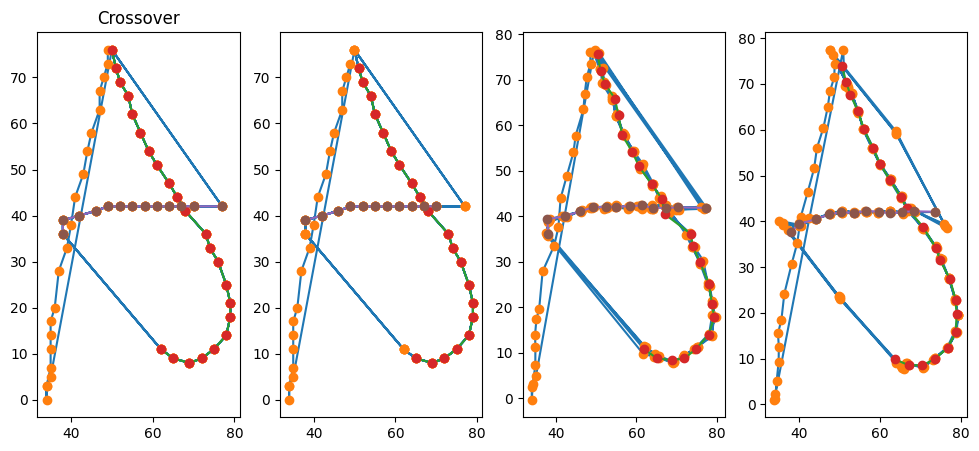

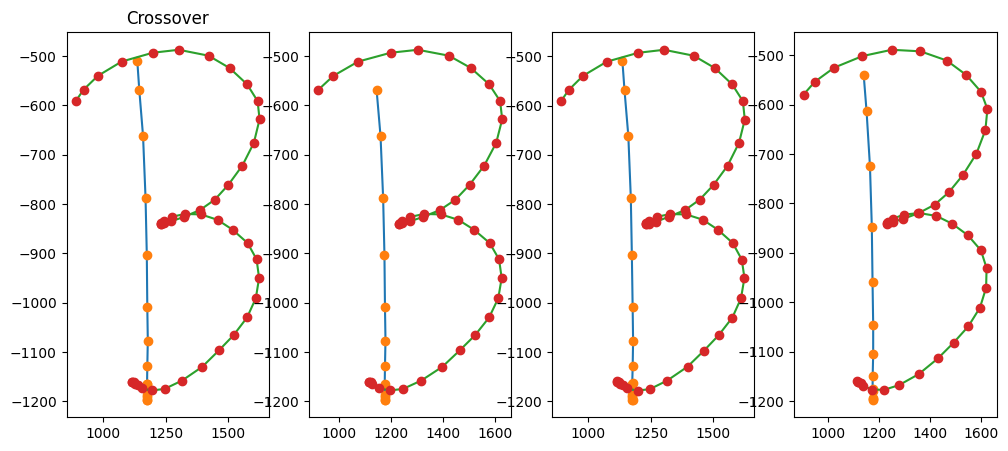

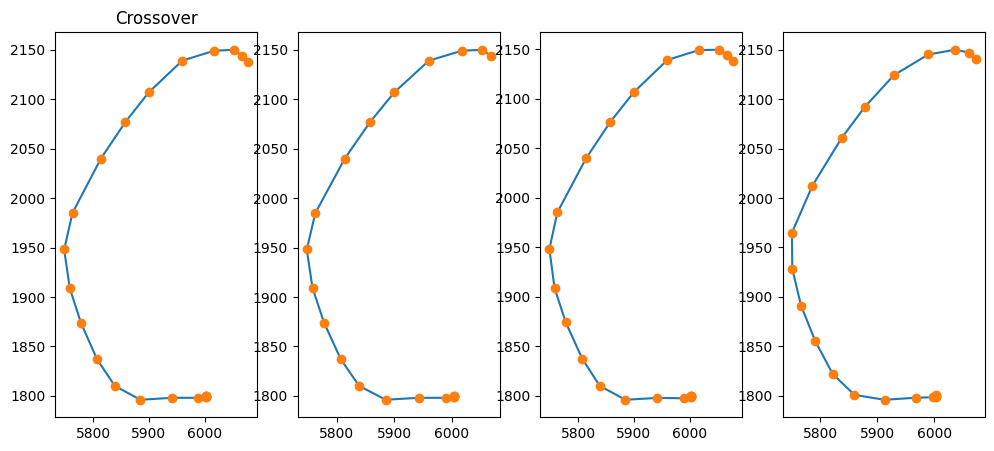

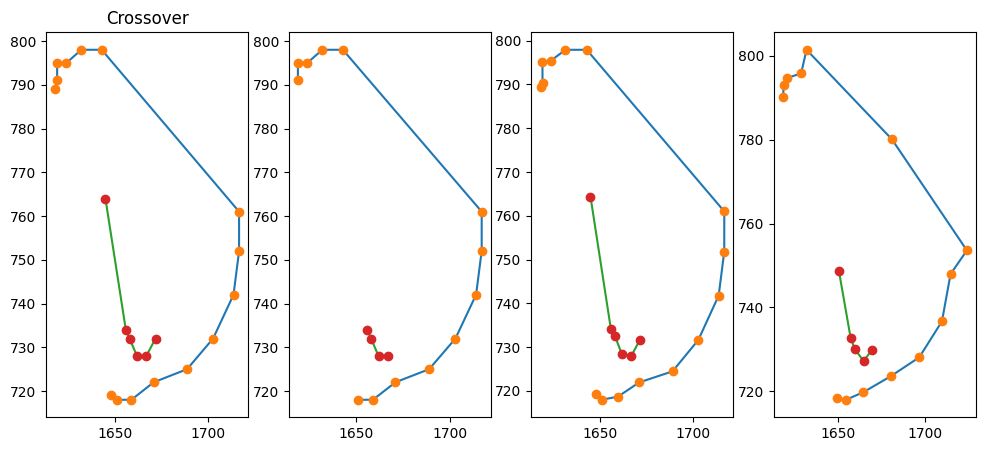

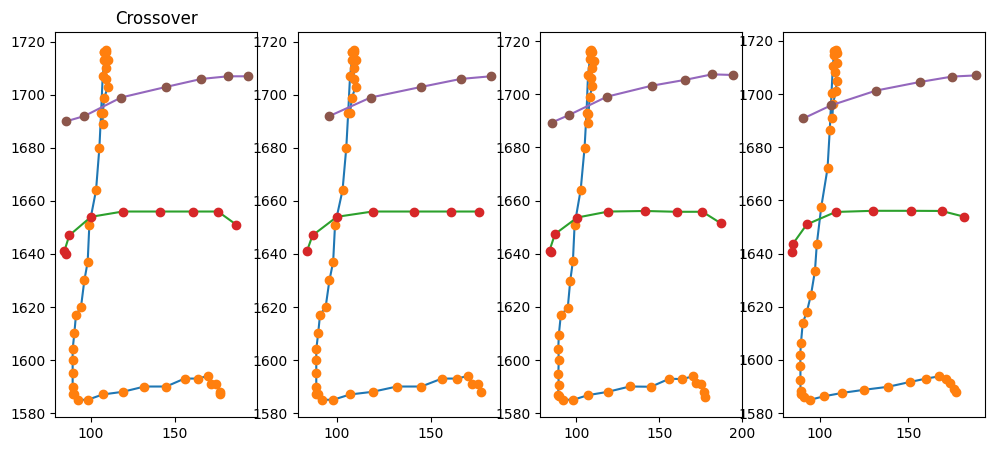

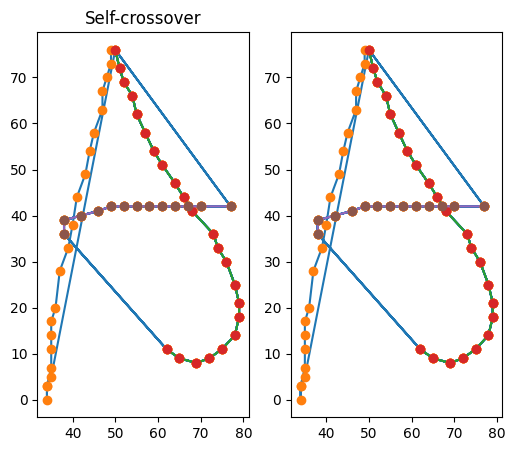

In [15]:
for i in range(len(prototypes)):
        
    render_samples([prototypes[i], shorten(prototypes[i]), random_move(prototypes[i], max_dist=(.3, .3)), spline_crossover(shorten(prototypes[i]), random_move(prototypes[i], max_dist=(.3, .3)))], "Crossover")

# Sanity testing
render_samples([prototypes[0], spline_crossover(prototypes[0], prototypes[0])], "Self-crossover")

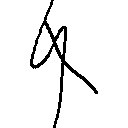

In [16]:
s2i = Strokes2ImageConverter()
#s2i.strokes_to_image(strokes=prototypes[0])
#s2i.strokes_to_image(strokes=prototypes[1])
#s2i.strokes_to_image(strokes=merge_points(spline_crossover(shorten(prototypes[i]), merge_points(prototypes[i], 10)), distance_threshold=10), padding=(5, 5))
img = s2i.strokes_to_image(strokes=spline_crossover(shorten(data[65][80]), data[65][6]))
img

# This block can be used to show some interpolations between samples, including those across character classes



At this point it is possible to generate, mutate and cross-over samples for each character class. The next goal is to combine these steps on a population resembling a single generation of the evolutionary algorithm. Creating the first generation of samples must be done using only the prototypes of each character class - perhaps with some first mutations. 

In [ ]:
from dataclasses import dataclass, field


@dataclass
class Sample():
    fitness: float
    origin: int 
    strokes: list[list[tuple[float, float]]] = field(default_factory=list)

s = Sample(1, 1, [[(3, 2), (3, 3)], [(1,1)]])
    

In [ ]:
def mutate(population: list[Sample], p: float =0.5, mutation_params={}) -> list[Sample]:
    
    mutated_population: list[Sample] = []
    for sample in population: 
        if np.random.rand() < p:
            sample = sample #TODO: mutation
        
        mutated_population.append(sample)
        
    return mutated_population

def crossover(population: list[Sample]):

    probabilities = [sample.fitness for sample in population]
    normalized_probabilities = probabilities / np.sum(probabilities) # These can never be negative
    pairs = np.random.choice(population, size=(len(population), 2), p=normalized_probabilities)

    next_generation: list[Sample] = []
    # At this point we have pairs of shape (pop_size, 2)
    for p1, p2 in pairs:         
        next_generation_strokes = spline_crossover(p1.strokes, p2.strokes)
        next_generation.append(Sample(0.0, p1.origin, next_generation_strokes))
    
    return next_generation

n_samples_per_class = 100  # Population size for each class in every generation 

test = [ Sample(1.0 * i, i, []) for i in range(50)]
print(test)
mutated_test = crossover(mutate(test))
print(mutated_test)

    

In [ ]:
import torch
from torchsummary import summary

from CIGNN_experimental.models.autoencoder.unipen_synth_ae import UnipenSyntheticAutoencoder

device = torch.device("cuda")

ae = UnipenSyntheticAutoencoder()
ae.to(device)

summary(ae, input_size=(3, 128, 128))


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()